1. Fashion MNIST contains raw 28x28 pixel images. Why is Deep Learning more
suitable than traditional ML for classifying raw image data?
Ans: Deep Learning is more suitable for raw image data like Fashion MNIST because it can automatically learn important visual features (edges, shapes, textures, patterns) directly from pixels. Traditional ML usually requires manual feature extraction, where humans must define image features before classification. Deep Learning models, especially CNNs, learn these features automatically and handle high-dimensional image data efficiently.

2. The DL workflow follows a fixed sequence of stages. List the stages of the Deep
Learning workflow in order.
Ans: Typical stages of the Deep Learning workflow in order:

Data Collection
Data Preprocessing
Train-Test Split
Model Selection / Architecture Design
Model Training
Validation & Hyperparameter Tuning
Model Evaluation
Deployment / Prediction

3. A biological neuron fires only when incoming signals exceed a threshold. What
is the artificial equivalent of this threshold mechanism in a neural network?
Ans: The artificial equivalent of the biological neuron’s threshold mechanism is the activation function combined with a bias term in a neural network neuron. The neuron produces an output only after the weighted sum passes through the activation function.

4. You must choose between an ANN and a CNN for Fashion MNIST. What
property of CNNs makes them better suited for image data than a plain ANN?
Ans:CNNs are better suited for image data because they use convolutional layers that automatically detect spatial features and local patterns such as edges, textures, and shapes. CNNs also preserve spatial relationships between pixels, unlike a plain ANN which treats all pixels independently.

5. Deep Learning was theorized decades ago but became practical only
recently. Name two factors that enabled the rise of modern Deep Learning?
Ans:Two major factors that enabled the rise of modern Deep Learning are:

Availability of large datasets (Big Data)
Powerful hardware such as GPUs/TPUs for fast parallel computation


In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
import matplotlib.pyplot as plt

In [5]:
# Load Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape :", X_train.shape)
print("Testing Images Shape :", X_test.shape)

# Normalize pixel values (0-255 --> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 21s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images Shape : (60000, 28, 28)
Testing Images Shape : (10000, 28, 28)


In [6]:
ann_model = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_ann = ann_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8295 - loss: 0.4747 - val_accuracy: 0.8545 - val_loss: 0.4034
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8696 - loss: 0.3567 - val_accuracy: 0.8616 - val_loss: 0.3791
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8820 - loss: 0.3206 - val_accuracy: 0.8699 - val_loss: 0.3570
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8881 - loss: 0.3007 - val_accuracy: 0.8716 - val_loss: 0.3595
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8939 - loss: 0.2836 - val_accuracy: 0.8627 - val_loss: 0.3732
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8989 - loss: 0.2715 - val_accuracy: 0.8813 - val_loss: 0.3275
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9038 - loss: 0.2568 - val_accuracy: 0.8864 - val_loss: 0.3209
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9070 - loss: 0.245

In [8]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

print(X_train_cnn.shape)

(60000, 28, 28, 1)


In [9]:
cnn_model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.25),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')

])

c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

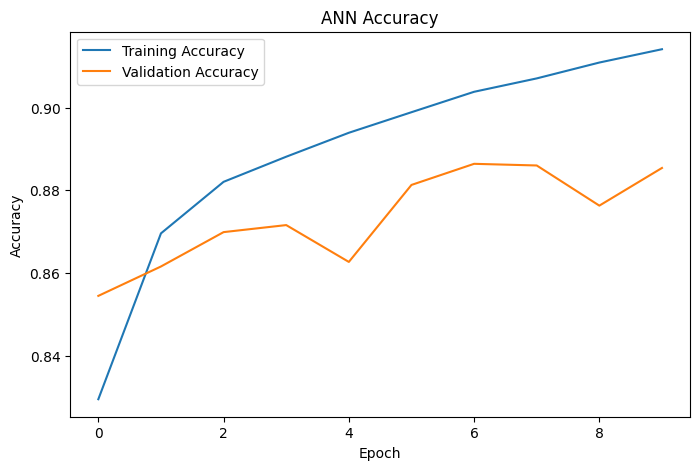

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

history_cnn not found. Run and assign training like:
history_cnn = cnn_model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=10, batch_size=32)


C:\Users\Aaryan\AppData\Local\Temp\ipykernel_21892\3897389970.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


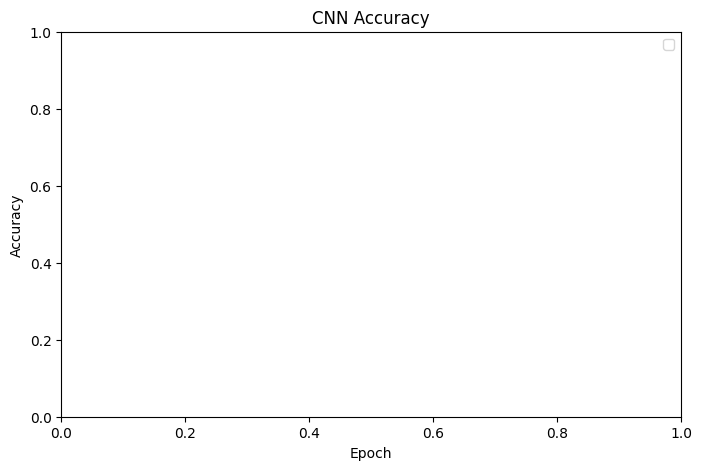

In [15]:
plt.figure(figsize=(8,5))

if 'history_cnn' in globals():
    plt.plot(history_cnn.history.get('accuracy', history_cnn.history.get('acc')), label='Training Accuracy')
else:
    print("history_cnn not found. Run and assign training like:\n"
          "history_cnn = cnn_model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=10, batch_size=32)")
if 'history_cnn' in globals():
    val = history_cnn.history.get('val_accuracy', history_cnn.history.get('val_acc'))
    if val is not None:
        plt.plot(val, label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

history_cnn not found. Train the CNN first with:
history_cnn = cnn_model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=10, batch_size=32)


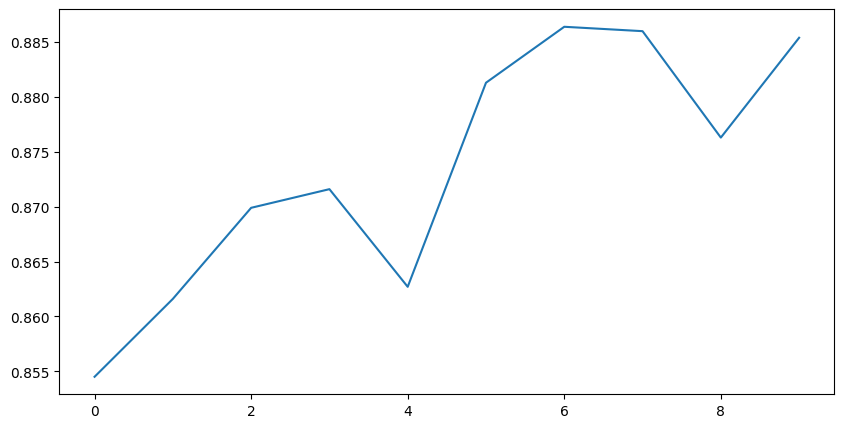

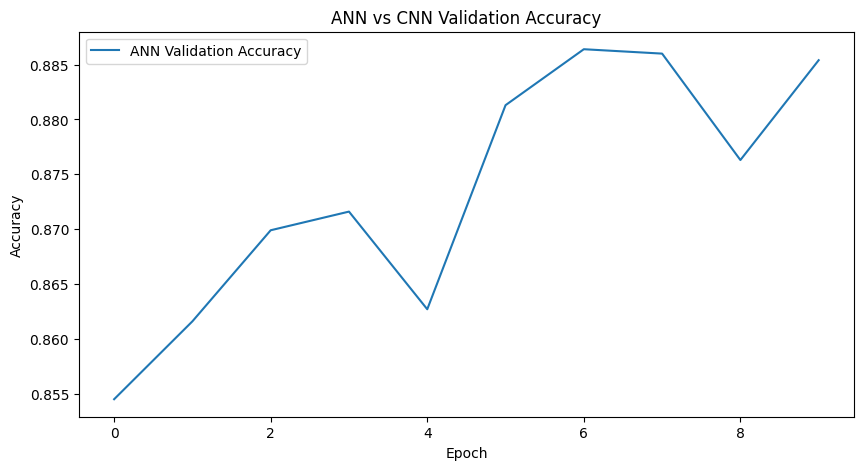

C:\Users\Aaryan\AppData\Local\Temp\ipykernel_21892\2399708047.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


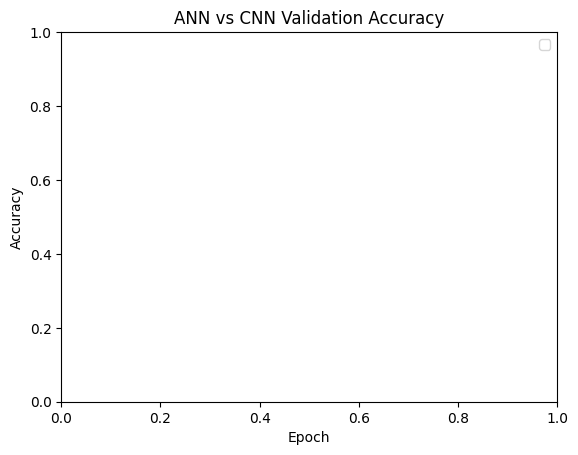

In [17]:
plt.figure(figsize=(10,5))

plt.plot(history_ann.history['val_accuracy'], label='ANN Validation Accuracy')

plt.figure(figsize=(10,5))

plt.plot(history_ann.history['val_accuracy'], label='ANN Validation Accuracy')

if 'history_cnn' in globals():
    plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')
else:
    print("history_cnn not found. Train the CNN first with:\n"
          "history_cnn = cnn_model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=10, batch_size=32)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")

plt.legend()

plt.show()

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")

plt.legend()

plt.show()

In [18]:
ann_loss, ann_acc = ann_model.evaluate(X_test, y_test)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)

print("ANN Test Accuracy :", ann_acc)
print("CNN Test Accuracy :", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8854 - loss: 0.3338
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1373 - loss: 2.3094
ANN Test Accuracy : 0.8853999972343445
CNN Test Accuracy : 0.13729999959468842


### Section-c

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [23]:
df = pd.DataFrame(
    X_test.reshape(X_test.shape[0], -1),
    columns=[f'pixel_{i}' for i in range(X_test.shape[1] * X_test.shape[2])]
)
df['label'] = y_test
df.head()
df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783,label
0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,9
1,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.011765,0.0,0.011765,0.682353,0.741176,0.262745,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.003922,0.000000,...,0.227451,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.082353,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.007843,0.0,0.003922,0.003922,0.0,0.000000,0.000000,...,0.047059,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,6


In [24]:
df.isnull().sum()

pixel_0      0
pixel_1      0
pixel_2      0
pixel_3      0
pixel_4      0
            ..
pixel_780    0
pixel_781    0
pixel_782    0
pixel_783    0
label        0
Length: 785, dtype: int64

In [25]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [26]:
X = X / 255.0

In [27]:
X = X.reshape(-1, 28, 28, 1)

In [28]:
y = to_categorical(y, 10)

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [32]:
history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1025 - loss: 2.3008 - val_accuracy: 0.1688 - val_loss: 2.2793
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3809 - loss: 1.6098 - val_accuracy: 0.5981 - val_loss: 1.0874
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5320 - loss: 1.1810 - val_accuracy: 0.6656 - val_loss: 0.9604
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5819 - loss: 1.0905 - val_accuracy: 0.6794 - val_loss: 0.9225
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6044 - loss: 1.0206 - val_accuracy: 0.6762 - val_loss: 0.8852
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6264 - loss: 0.9972 - val_accuracy: 0.6856 - val_loss: 0.8517
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6283 - loss: 0.9737 - val_accuracy: 0.6881 - val_loss: 0.8375
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6384 - loss: 0.9569 - val_accura

In [33]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6885 - loss: 0.8357

Test Accuracy: 0.6884999871253967


In [34]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [35]:
cm = confusion_matrix(true_classes,predicted_classes)
print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[132   3  12   9   5   0   6   0   1   0]
 [  3 159   2  26   7   0   1   0   0   0]
 [  2   0 143   0  55   0  20   0   3   0]
 [ 28  11   5 127  18   0   8   0   2   0]
 [  0   0  45   8 124   0   8   0   0   1]
 [  0   1   0   0   0 124   0  55   7  24]
 [ 39   1  70  14  34   0  35   0   5   0]
 [  0   0   0   0   0   9   0 177   2  22]
 [  1   0  23   2   2   0   2   0 161   0]
 [  0   1   0   0   1   1   0  18   0 195]]


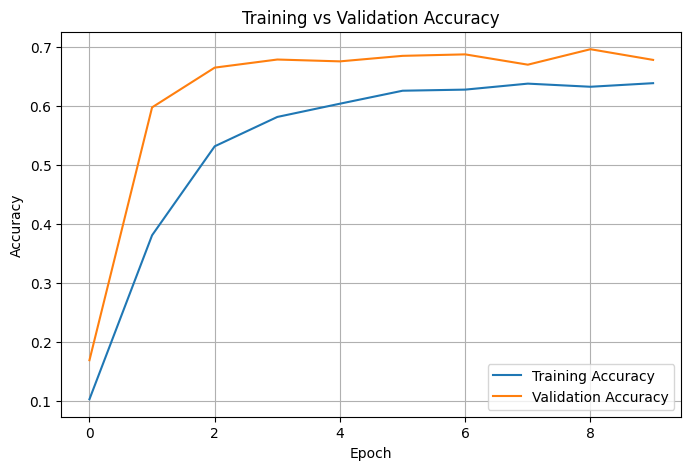

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()